# Figure 1 Overview Helpers

This notebook reproduces the plot components used around report Figure 1: the ideal sparse attention patterns, the minimal-model staged KL/loss curves, and individual attention snapshots. The W&B runs are selected from the `ICLR-Fig1` tag in `r-alvarezlucendo16/incremental-learning`.


In [1]:
from analysis.utils import (
    fetch_runs,
    plot_combined_heads_individual,
    plot_kl_divergence_simple,
    plot_val_loss_simple,
    REPORT_HEAD_COLORS,
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


SAVE_FIGURES = False


def output_path(name):
    return f"analysis/figures/{name}" if SAVE_FIGURES else None


## W&B Run Selection

The report-facing run is `i0a1de0a`, discovered under the `ICLR-Fig1` tag. The table below keeps the tag lookup visible so alternate runs with the same sweep tag can be inspected.


In [2]:
FIGURE_TAG = "ICLR-Fig1"
SELECTED_RUN_ID = "i0a1de0a"

runs = fetch_runs(tags_any=[FIGURE_TAG])
pd.DataFrame(
    [{"run_id": run.id, "name": run.name, "state": run.state, "tags": list(run.tags)} for run in runs]
)


,run_id,name,state,tags
0,i0a1de0a,apricot-paper-1676,finished,[ICLR-Fig1]
1,iai8ang2,decent-gorge-1677,finished,[ICLR-Fig1]
2,xy9noxwc,cool-eon-1677,finished,[ICLR-Fig1]
3,hhfk9daj,hearty-puddle-1679,finished,[ICLR-Fig1]
4,dayi1xj5,fearless-capybara-1686,finished,[ICLR-Fig1]


## Staged Loss And KL Curves

These curves support the staged-learning panels in Figure 1 and the main text discussion: the transformer first matches the one-feature predictor, then the two-feature predictor, and finally the full three-feature predictor.


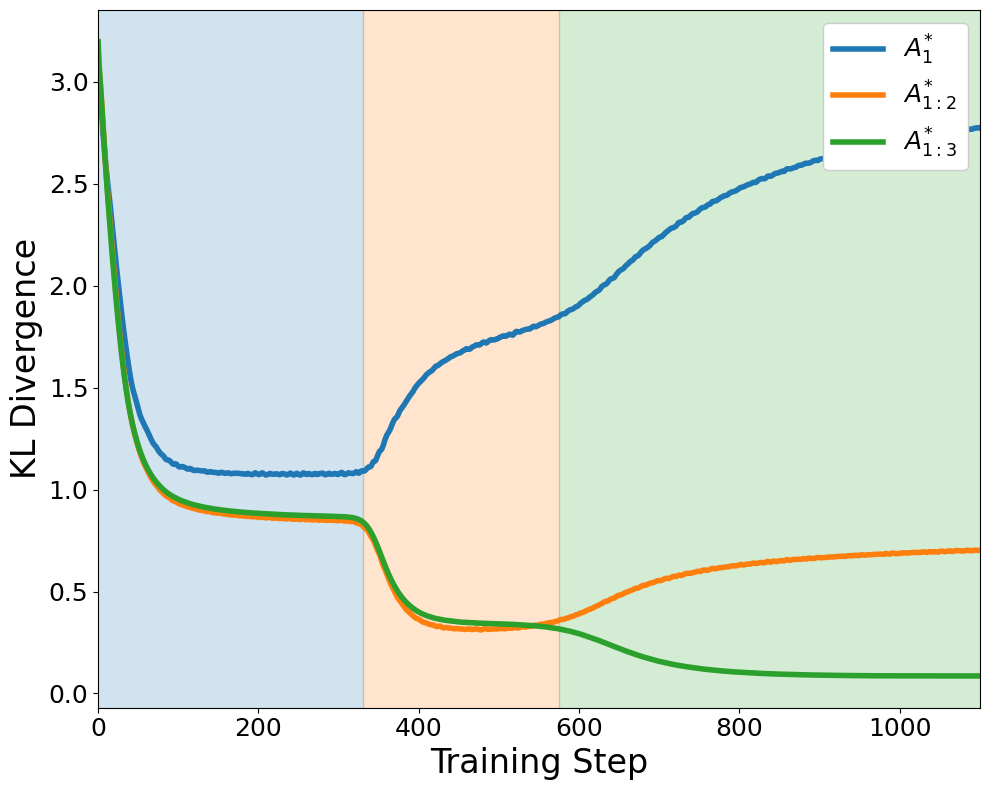

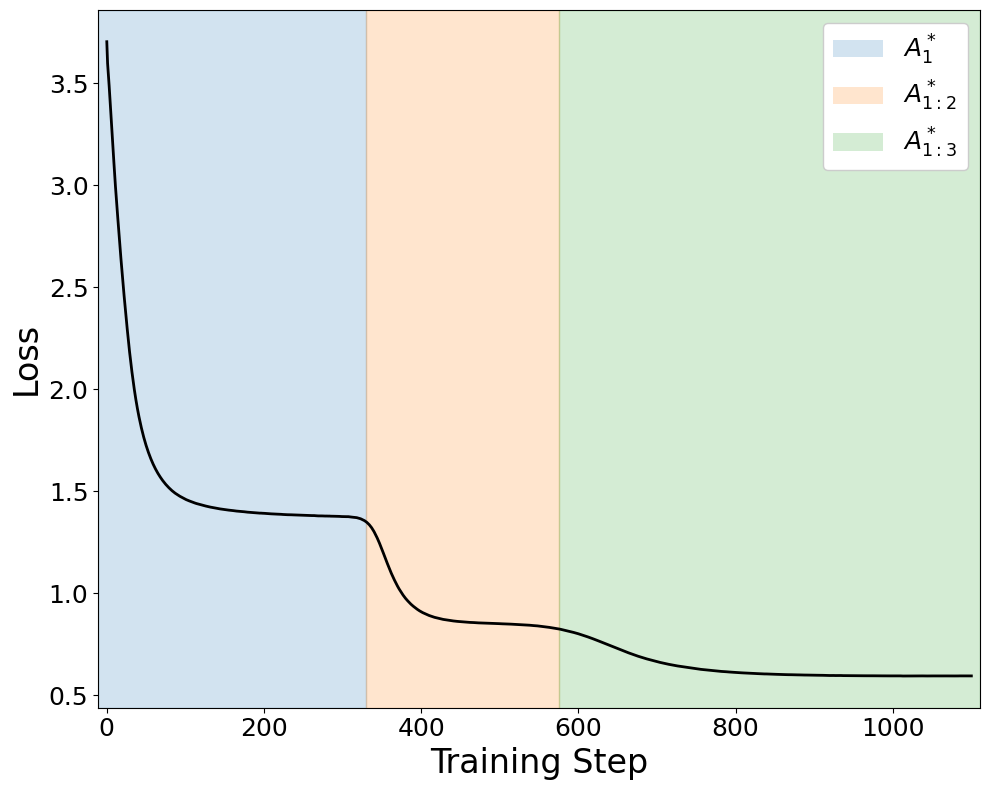

In [3]:
plot_kl_divergence_simple(
    run_id=SELECTED_RUN_ID,
    divergence_steps=[2330, 2575],
    max_steps=3100,
    figsize=(10, 8),
    learnable=False,
    shift_steps=True,
    save_name=output_path("figure1-kl-divergence"),
)

plot_val_loss_simple(
    run_id=SELECTED_RUN_ID,
    divergence_steps=[2330, 2575],
    max_steps=3100,
    figsize=(10, 8),
    shift_steps=True,
    save_name=output_path("figure1-val-loss"),
)


## Individual Attention Snapshots

These head-composition snapshots show the transition from competition on the most important interval to specialization across intervals.


wandb:   1 of 1 files downloaded.  


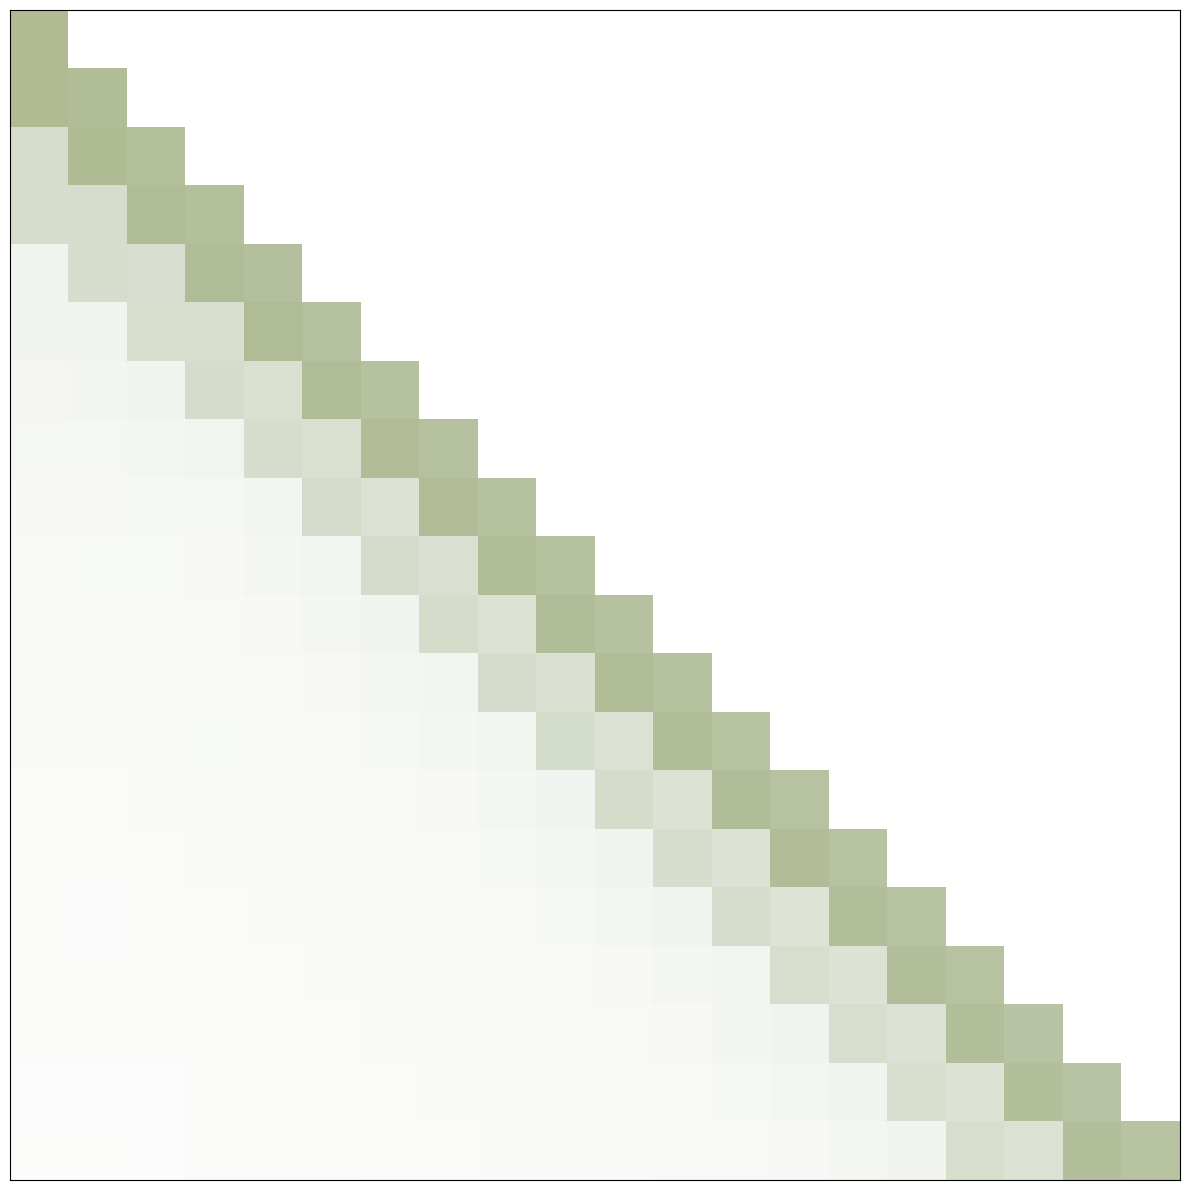

wandb:   1 of 1 files downloaded.  


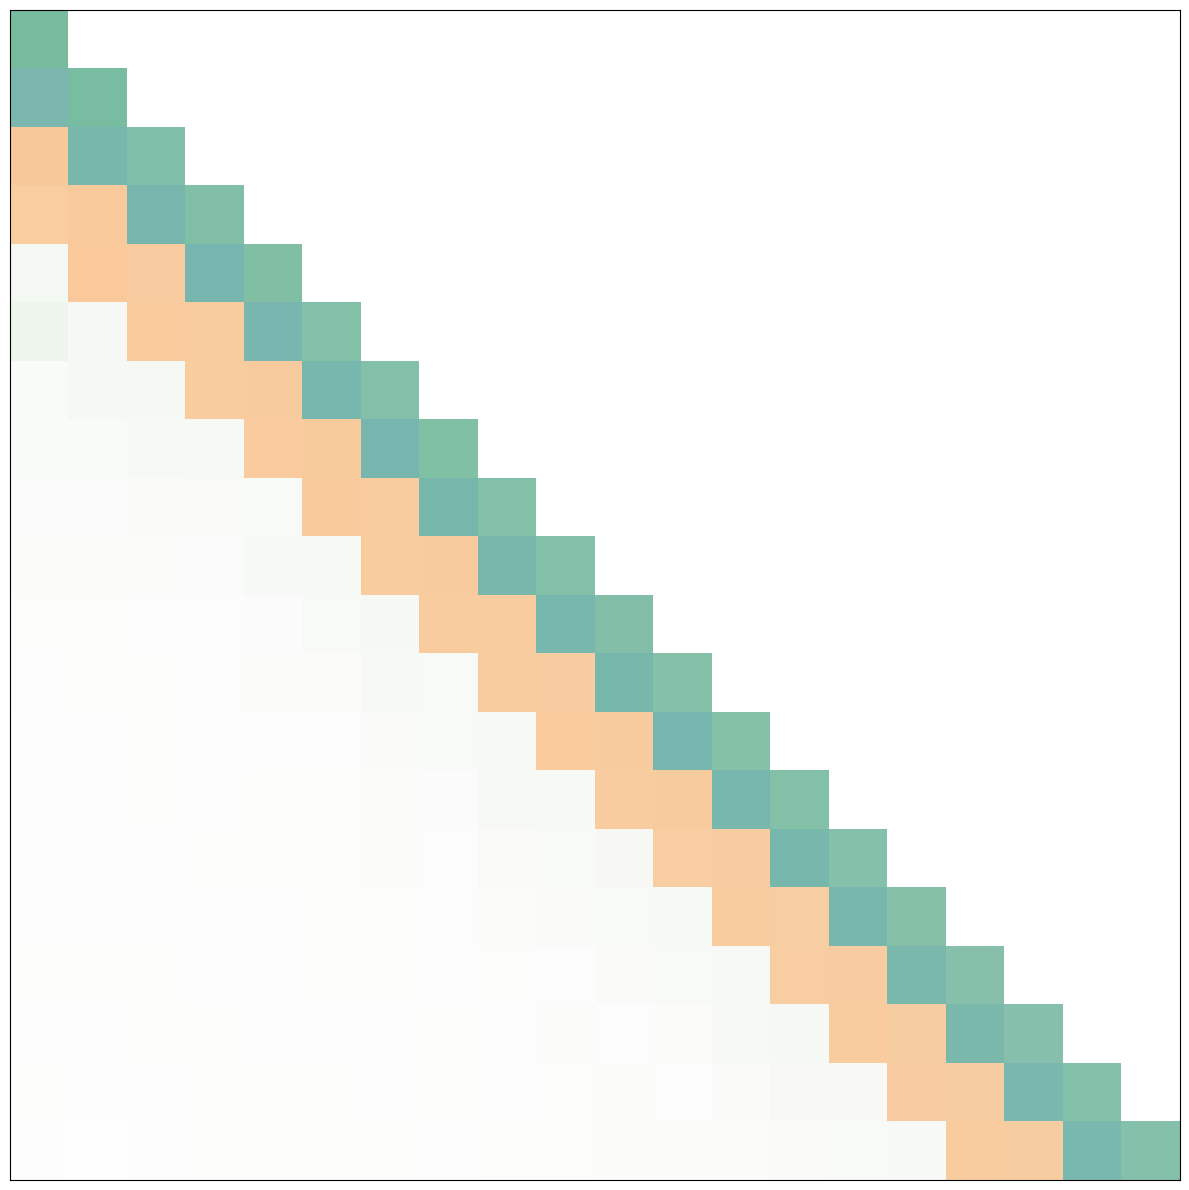

wandb:   1 of 1 files downloaded.  


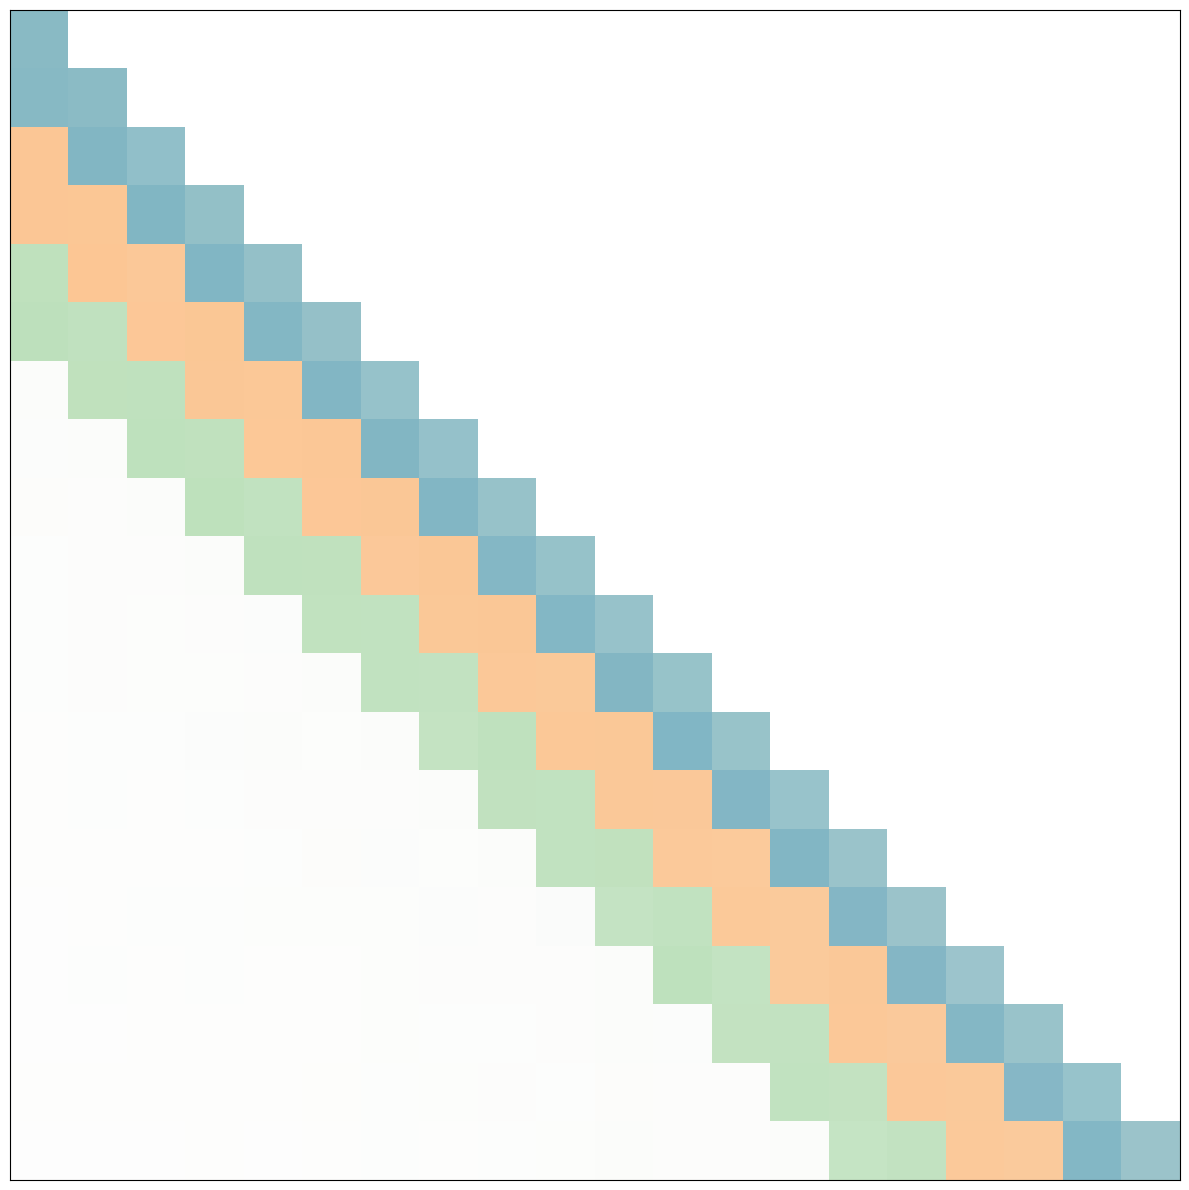

In [4]:
for step in [150, 500, 1000]:
    plot_combined_heads_individual(
        SELECTED_RUN_ID,
        step=step,
        split="val",
        gamma=1,
        save_name=output_path(f"figure1-combined-heads-step-{step}"),
    )


## Ideal Sparse Attention Patterns

The three panels below are the idealized attention masks from the report overview: each head copies from one interval of positions.


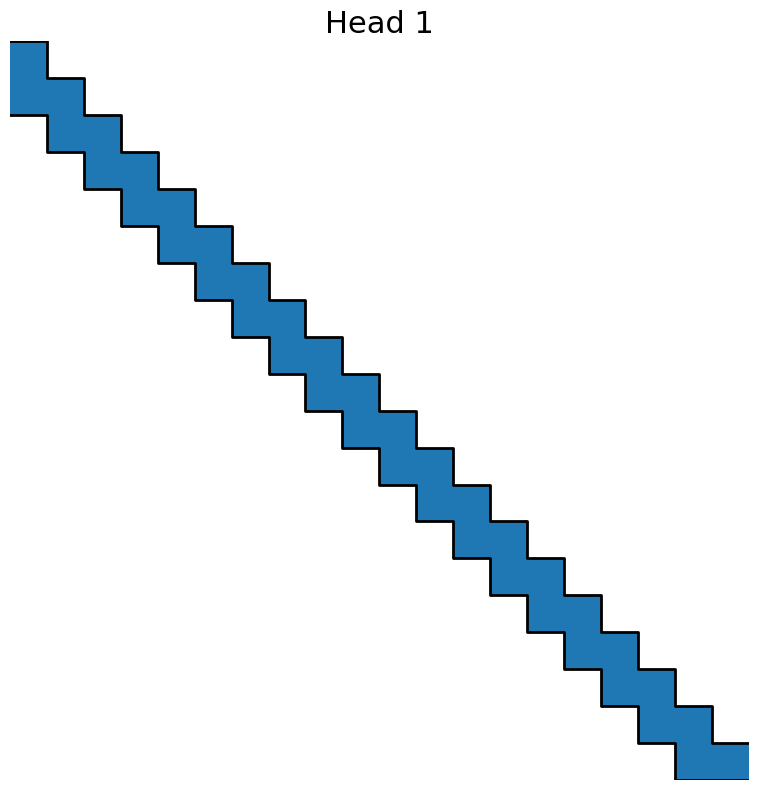

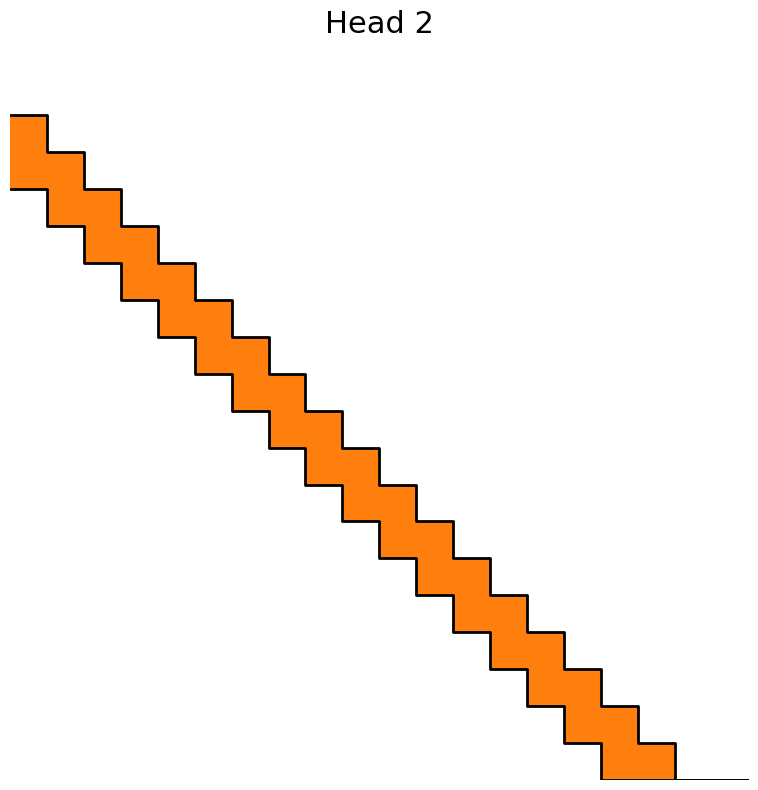

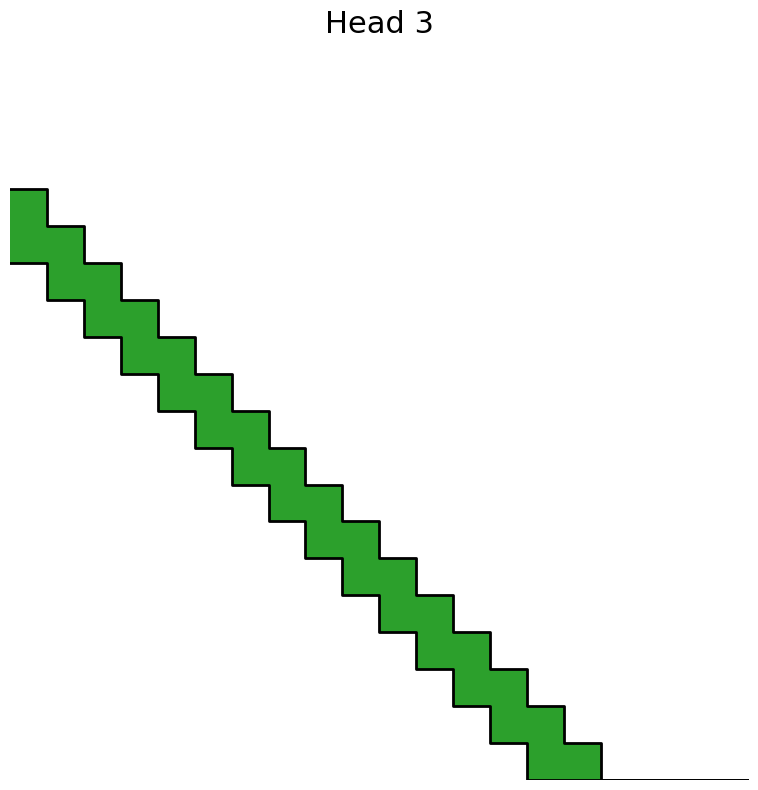

In [5]:
def plot_ideal_attention(diagonal_rows, staircase_offsets, color, title, save_name=None):
    data = np.zeros((20, 20))
    for row_offset in diagonal_rows:
        np.fill_diagonal(data[row_offset:], 1)

    fig, ax = plt.subplots(figsize=(8, 8))
    sns.heatmap(data, cmap=["white", color], cbar=False, square=True, ax=ax)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=22)

    x_edges = np.arange(0, 20.5, 1)
    for off in staircase_offsets:
        y_centers = np.clip(np.arange(20) - off, 0, 20)
        y_post = np.r_[y_centers, y_centers[-1]]
        ax.step(x_edges, y_post, where="post", color="black", linewidth=2)

    plt.tight_layout()
    if save_name:
        fig.savefig(save_name, bbox_inches="tight", dpi=300)
    else:
        plt.show()

plot_ideal_attention(range(0, 2), [0, -2], REPORT_HEAD_COLORS[0], "Head 1", output_path("ideal-attention-head-1.pdf"))
plot_ideal_attention(range(2, 4), [-2, -4], REPORT_HEAD_COLORS[1], "Head 2", output_path("ideal-attention-head-2.pdf"))
plot_ideal_attention(range(4, 6), [-4, -6], REPORT_HEAD_COLORS[2], "Head 3", output_path("ideal-attention-head-3.pdf"))
